### Downstream analysis RMI & RPI indexes, module: metal_indexes_rb
Raw reads count are aggregated for all the samples using the geomosaic command:
```bash
geomosaic gather -s gmsetup -p redox_metal_plasticity_index
```

plot of the variation in the Redox Metabolic Index (A) and the Metal Plasticity Index (B) against temperature for a series of metagenomes obtained using the read-based analysis stream.

In [23]:
# Imports
library(phyloseq)
library(readr)
library(dplyr)
library(tidyr)
library(stringr)
library(ggplot2)
library(vegan)
#library(ggrepel)

options(readr.show_col_types = FALSE)

In [24]:
install.packages("svglite")

Warning message in install.packages("svglite"):
“installation of package ‘svglite’ had non-zero exit status”
Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [25]:
theme_glab <- function(base_size = 11, base_family = "") {
  theme_bw(base_size = base_size, base_family = base_family) %+replace%
    theme(
      legend.background = element_blank(),
      legend.title      = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        size = rel(0.65),
        hjust = 0
      ),
      legend.text       = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        size = rel(0.65)
      ),
      legend.key.size   = unit(0.8, "lines"),
      plot.title        = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        hjust = 0.5, 
        face = "bold"
      ),
      axis.title        = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        size = rel(0.65)
      ),
      axis.text         = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        size = rel(0.65)
      ),
      panel.grid.major  = element_blank(),
      panel.grid.minor  = element_blank(),
      panel.border      = element_rect(
        fill = NA,
        colour = rgb(100, 100, 100, maxColorValue = 255)
      ),
      complete = TRUE
    )
}

In [26]:
env <- as.data.frame(read_delim("../tables/cr18_env_geomosaicPlot.csv", 
                  delim = ",",
                  skip = 1, 
                  locale = locale(decimal_mark = ",")))

rownames(env) <- env$Geomosaic_sample


In [27]:
df <- read.delim("/home/edotacca/working_dir/geomosaic_cookbook/tables/gm_gathering/redox_metal_plasticity_index_2/redox_metal_indexes.tsv", row.names = 1)


In [28]:
df

,redox_metabolic_index,metal_plasticty_index,acceptors_metals,donors_metal,acceptor_substrates,donor_substrates
,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
ERR1877670,4.4773,3.4965,Cu;Fe;Ln;Mo;Ni;NiCu,CuMo;Fe;Mo;MoCo;Ni;W,Arsenate;CO2;Methanol;Nitrate;Nitric oxide;Nitrite;Oxygen;Sulfate,Arsenite;CO;Hydrogen;Hydrogen/CO2;Hydroxylamine;Nitrite;Organic carbon;Sulfide;Sulfite;Sulfur;Thiosulfate
SRR37709773,3.9890,2.7081,Cu;Fe;Mg;Mo;Ni;NiCu,Fe;Mo;Ni,Arsenate;CO2;DMSO;Lactate;Nitrate;Nitrite;Oxygen;Sulfate;Sulfite,Hydrogen;Nitrite;Organic carbon;Sulfide;Sulfite;Thiosulfate
SRR38179882,4.4998,3.2958,Cu;Fe;Mo;Ni;NiCu,CuMo;Fe;Mo;MoCo;Ni;W,Arsenate;CO2;DMSO;Nitric oxide;Nitrite;Nitrous oxide;Oxygen;Sulfate;Sulfite,Arsenite;CO;Hydrogen;Hydrogen/CO2;Nitrite;Organic carbon;Sulfide;Sulfite;Thiosulfate;Water
SRR38781006,3.6889,2.7081,Cu;Fe;Mg;Mo;Ni;NiCu,Fe;Mo;Ni,Arsenate;CO2;DMSO;Lactate;Nitrate;Nitric oxide;Nitrite;Oxygen;Sulfate;Sulfite,Hydrogen;Nitrite;Organic carbon;Sulfite
SRR3963449,4.6821,3.2189,Cu;Fe;Ln;Mo,Cu;CuMo;Fe;Mo;MoCo;Ni;W,Ammonia/Methane;Arsenate;Methanol;Nitrate;Nitric oxide;Nitrite;Nitrous oxide;Oxygen;Sulfate,Ammonia/Methane;Arsenite;CO;Hydrogen;Hydrogen/CO2;Hydroxylamine;Nitrite;Organic carbon;Sulfide;Sulfite;Thiosulfate;Water
ERR1877774,4.4998,3.4965,Cu;Fe;Ln;Mo;Ni;NiCu,CuMo;Fe;Mo;MoCo;Ni;W,Arsenate;CO2;Methanol;Nitrate;Nitric oxide;Nitrite;Nitrous oxide;Oxygen;Sulfate,Arsenite;CO;Hydrogen;Hydrogen/CO2;Hydroxylamine;Nitrite;Organic carbon;Sulfite;Sulfur;Thiosulfate
ERR1877776,3.6889,2.9444,Cu;Fe;Ln;Mo,CuMo;Fe;Mo;MoCo;W,Arsenate;Methanol;Nitrate;Nitrite;Oxygen,Arsenite;CO;Hydrogen;Hydrogen/CO2;Nitrite;Organic carbon;Sulfite;Thiosulfate
SRR38179869,4.3944,3.2958,Cu;Fe;Mo;Ni;NiCu,CuMo;Fe;Mo;MoCo;Ni;W,Arsenate;CO2;Nitrate;Nitric oxide;Nitrite;Nitrous oxide;Oxygen;Sulfate;Sulfite,Arsenite;CO;Hydrogen;Hydrogen/CO2;Nitrite;Organic carbon;Sulfide;Thiosulfate;Water
SRR38179880,4.5951,3.4965,Cu;Fe;Ln;Mo;Ni;NiCu,CuMo;Fe;Mo;MoCo;Ni;W,Arsenate;CO2;DMSO;Methanol;Nitrate;Nitric oxide;Nitrite;Nitrous oxide;Oxygen;Sulfate;Sulfite,Arsenite;CO;Hydrogen;Hydrogen/CO2;Nitrite;Organic carbon;Sulfide;Sulfite;Thiosulfate


In [29]:
df_2 <- read.delim("/home/edotacca/working_dir/geomosaic_cookbook/tables/gm_gathering/redox_metal_plasticity_index_3/redox_metal_indexes.tsv", row.names = 1)


In [30]:
df_2

,redox_metabolic_index,metal_plasticty_index,acceptors_metals,donors_metal,acceptor_substrates,donor_substrates
,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
ERR1877670,4.4773,3.4965,Cu;Fe;Ln;Mo;Ni;NiCu,CuMo;Fe;Mo;MoCo;Ni;W,Arsenate;CO2;Methanol;Nitrate;Nitric oxide;Nitrite;Oxygen;Sulfate,Arsenite;CO;Hydrogen;Hydrogen/CO2;Hydroxylamine;Nitrite;Organic carbon;Sulfide;Sulfite;Sulfur;Thiosulfate
SRR37709773,3.9890,2.7081,Cu;Fe;Mg;Mo;Ni;NiCu,Fe;Mo;Ni,Arsenate;CO2;DMSO;Lactate;Nitrate;Nitrite;Oxygen;Sulfate;Sulfite,Hydrogen;Nitrite;Organic carbon;Sulfide;Sulfite;Thiosulfate
SRR38179882,4.4998,3.2958,Cu;Fe;Mo;Ni;NiCu,CuMo;Fe;Mo;MoCo;Ni;W,Arsenate;CO2;DMSO;Nitric oxide;Nitrite;Nitrous oxide;Oxygen;Sulfate;Sulfite,Arsenite;CO;Hydrogen;Hydrogen/CO2;Nitrite;Organic carbon;Sulfide;Sulfite;Thiosulfate;Water
SRR38781006,3.6889,2.7081,Cu;Fe;Mg;Mo;Ni;NiCu,Fe;Mo;Ni,Arsenate;CO2;DMSO;Lactate;Nitrate;Nitric oxide;Nitrite;Oxygen;Sulfate;Sulfite,Hydrogen;Nitrite;Organic carbon;Sulfite
SRR3963449,4.6821,3.2189,Cu;Fe;Ln;Mo,Cu;CuMo;Fe;Mo;MoCo;Ni;W,Ammonia/Methane;Arsenate;Methanol;Nitrate;Nitric oxide;Nitrite;Nitrous oxide;Oxygen;Sulfate,Ammonia/Methane;Arsenite;CO;Hydrogen;Hydrogen/CO2;Hydroxylamine;Nitrite;Organic carbon;Sulfide;Sulfite;Thiosulfate;Water
ERR1877774,4.4998,3.4965,Cu;Fe;Ln;Mo;Ni;NiCu,CuMo;Fe;Mo;MoCo;Ni;W,Arsenate;CO2;Methanol;Nitrate;Nitric oxide;Nitrite;Nitrous oxide;Oxygen;Sulfate,Arsenite;CO;Hydrogen;Hydrogen/CO2;Hydroxylamine;Nitrite;Organic carbon;Sulfite;Sulfur;Thiosulfate
ERR1877776,3.6889,2.9444,Cu;Fe;Ln;Mo,CuMo;Fe;Mo;MoCo;W,Arsenate;Methanol;Nitrate;Nitrite;Oxygen,Arsenite;CO;Hydrogen;Hydrogen/CO2;Nitrite;Organic carbon;Sulfite;Thiosulfate
SRR38179869,4.3944,3.2958,Cu;Fe;Mo;Ni;NiCu,CuMo;Fe;Mo;MoCo;Ni;W,Arsenate;CO2;Nitrate;Nitric oxide;Nitrite;Nitrous oxide;Oxygen;Sulfate;Sulfite,Arsenite;CO;Hydrogen;Hydrogen/CO2;Nitrite;Organic carbon;Sulfide;Thiosulfate;Water
SRR38179880,4.5951,3.4965,Cu;Fe;Ln;Mo;Ni;NiCu,CuMo;Fe;Mo;MoCo;Ni;W,Arsenate;CO2;DMSO;Methanol;Nitrate;Nitric oxide;Nitrite;Nitrous oxide;Oxygen;Sulfate;Sulfite,Arsenite;CO;Hydrogen;Hydrogen/CO2;Nitrite;Organic carbon;Sulfide;Sulfite;Thiosulfate


In [31]:
df_3 <- read.delim("../tables/gm_gathering/redox_metal_plasticity_index_4/redox_metal_indexes.tsv", row.names = 1)

In [32]:
df_3

,redox_metabolic_index,metal_plasticty_index,acceptors_metals,donors_metal,acceptor_substrates,donor_substrates,metal_plasticity_index
,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>
ERR1877670,4.4773,3.4965,Cu;Fe;Ln;Mo;Ni;NiCu,CuMo;Fe;Mo;MoCo;Ni;W,Arsenate;CO2;Methanol;Nitrate;Nitric oxide;Nitrite;Oxygen;Sulfate,Arsenite;CO;Hydrogen;Hydrogen/CO2;Hydroxylamine;Nitrite;Organic carbon;Sulfide;Sulfite;Sulfur;Thiosulfate,NA
SRR37709773,3.9890,2.7081,Cu;Fe;Mg;Mo;Ni;NiCu,Fe;Mo;Ni,Arsenate;CO2;DMSO;Lactate;Nitrate;Nitrite;Oxygen;Sulfate;Sulfite,Hydrogen;Nitrite;Organic carbon;Sulfide;Sulfite;Thiosulfate,NA
SRR38179882,4.4998,3.2958,Cu;Fe;Mo;Ni;NiCu,CuMo;Fe;Mo;MoCo;Ni;W,Arsenate;CO2;DMSO;Nitric oxide;Nitrite;Nitrous oxide;Oxygen;Sulfate;Sulfite,Arsenite;CO;Hydrogen;Hydrogen/CO2;Nitrite;Organic carbon;Sulfide;Sulfite;Thiosulfate;Water,NA
SRR38781006,3.6889,2.7081,Cu;Fe;Mg;Mo;Ni;NiCu,Fe;Mo;Ni,Arsenate;CO2;DMSO;Lactate;Nitrate;Nitric oxide;Nitrite;Oxygen;Sulfate;Sulfite,Hydrogen;Nitrite;Organic carbon;Sulfite,NA
SRR3963449,4.6821,3.2189,Cu;Fe;Ln;Mo,Cu;CuMo;Fe;Mo;MoCo;Ni;W,Ammonia/Methane;Arsenate;Methanol;Nitrate;Nitric oxide;Nitrite;Nitrous oxide;Oxygen;Sulfate,Ammonia/Methane;Arsenite;CO;Hydrogen;Hydrogen/CO2;Hydroxylamine;Nitrite;Organic carbon;Sulfide;Sulfite;Thiosulfate;Water,NA
ERR1877774,4.4998,3.4965,Cu;Fe;Ln;Mo;Ni;NiCu,CuMo;Fe;Mo;MoCo;Ni;W,Arsenate;CO2;Methanol;Nitrate;Nitric oxide;Nitrite;Nitrous oxide;Oxygen;Sulfate,Arsenite;CO;Hydrogen;Hydrogen/CO2;Hydroxylamine;Nitrite;Organic carbon;Sulfite;Sulfur;Thiosulfate,NA
ERR1877776,3.6889,2.9444,Cu;Fe;Ln;Mo,CuMo;Fe;Mo;MoCo;W,Arsenate;Methanol;Nitrate;Nitrite;Oxygen,Arsenite;CO;Hydrogen;Hydrogen/CO2;Nitrite;Organic carbon;Sulfite;Thiosulfate,NA
SRR38179869,4.3944,3.2958,Cu;Fe;Mo;Ni;NiCu,CuMo;Fe;Mo;MoCo;Ni;W,Arsenate;CO2;Nitrate;Nitric oxide;Nitrite;Nitrous oxide;Oxygen;Sulfate;Sulfite,Arsenite;CO;Hydrogen;Hydrogen/CO2;Nitrite;Organic carbon;Sulfide;Thiosulfate;Water,NA
SRR38179880,4.5951,3.4965,Cu;Fe;Ln;Mo;Ni;NiCu,CuMo;Fe;Mo;MoCo;Ni;W,Arsenate;CO2;DMSO;Methanol;Nitrate;Nitric oxide;Nitrite;Nitrous oxide;Oxygen;Sulfate;Sulfite,Arsenite;CO;Hydrogen;Hydrogen/CO2;Nitrite;Organic carbon;Sulfide;Sulfite;Thiosulfate,NA


SRR38179882 -> rumen
SRR38179869 -> rumen
SRR38179880 -> rumen
SRR38781006 -> human_gut
SRR38781006 -> human_gut
SRR37709773 -> humna_stool
SRR3963449  -> seawater
            -> seawater
            -> seawater
ERR1877670  -> soil
ERR1877774  -> soil
ERR1877776  -> soil
            -> hot_springs
            -> hot_springs
            -> hot_springs

"SRR38179882","SRR38781006","SRR37709773","SRR3963449","ERR1877670""rumen","human_gut","humna_stool","seawater","soil",

In [33]:
dt <- data.frame(samples = c("SRR38179882","SRR38781006","SRR37709773","SRR3963449","ERR1877670","ERR1877774","ERR1877776","SRR38179869","SRR38179880"), biome = c("rumen","human_gut","humna_stool","seawater","soil","soil","soil","rumen","rumen"))
rownames(dt) <- dt$samples

In [34]:
dt_2 <- data.frame(samples = c("SRR38179882","SRR38781006","SRR37709773","SRR3963449","ERR1877670","ERR1877774","ERR1877776","SRR38179869","SRR38179880","ERR599017","ERR599116","ERR599146"), biome = c("rumen","human_gut","humna_stool","seawater","soil","soil","soil","rumen","rumen","tara","tara","tara"))
rownames(dt_2) <- dt_2$samples

In [35]:
dt_3 <-  data.frame(samples = c("SRR38179882","SRR38781006","SRR37709773","SRR3963449","ERR1877670","ERR1877774","ERR1877776","SRR38179869","SRR38179880","ERR599017","ERR599116","ERR599146","ERR599132","ERR1877661","CR18_LE180416_F","CR18_LE180416_S","CR18_ER180415_F","CR18_ER180415_S","SRR38179866"), biome = c("rumen","human_gut","humna_stool","seawater","soil","soil","soil","rumen","rumen","tara","tara","tara","tara","soil","hot_spring","hot_spring","hot_spring","hot_spring","rumen"))
rownames(dt_3) <- dt_3$samples

In [36]:
dt_3

,samples,biome
,<chr>,<chr>
SRR38179882,SRR38179882,rumen
SRR38781006,SRR38781006,human_gut
SRR37709773,SRR37709773,humna_stool
SRR3963449,SRR3963449,seawater
ERR1877670,ERR1877670,soil
ERR1877774,ERR1877774,soil
ERR1877776,ERR1877776,soil
SRR38179869,SRR38179869,rumen
SRR38179880,SRR38179880,rumen


In [37]:
combined_df_3 <- merge(df_3, dt_3, by = 0, all.x = TRUE, )
combined_df_3$Row.names <- NULL
rownames(combined_df_3) <- combined_df_3$samples

In [38]:
combined_df_3

,redox_metabolic_index,metal_plasticty_index,acceptors_metals,donors_metal,acceptor_substrates,donor_substrates,metal_plasticity_index,samples,biome
,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>
CR18_ER180415_F,5.0499,3.7612,"['Cu', 'Fe', 'Ln', 'Mg', 'Mo', 'Ni', 'NiCu']","['Cu', 'CuMo', 'Fe', 'Mo', 'MoCo', 'Ni', 'W']","['Ammonia/Methane', 'Arsenate', 'CO2', 'DMSO', 'Lactate', 'Methanol', 'Nitrate', 'Nitric oxide', 'Nitrite', 'Nitrous oxide', 'Oxygen', 'Sulfate']","['Ammonia/Methane', 'Arsenite', 'CO', 'Hydrogen', 'Hydrogen/CO2', 'Hydroxylamine', 'Nitrite', 'Organic carbon', 'Sulfide', 'Sulfite', 'Sulfur', 'Thiosulfate', 'Water']",NA,CR18_ER180415_F,hot_spring
CR18_ER180415_S,4.9628,3.5835,"['Cu', 'Fe', 'Ln', 'Mo', 'Ni', 'NiCu']","['Cu', 'CuMo', 'Fe', 'Mo', 'MoCo', 'Ni', 'W']","['Ammonia/Methane', 'Arsenate', 'CO2', 'DMSO', 'Methanol', 'Nitrate', 'Nitric oxide', 'Nitrite', 'Nitrous oxide', 'Oxygen', 'Sulfate']","['Ammonia/Methane', 'Arsenite', 'CO', 'Hydrogen', 'Hydrogen/CO2', 'Hydroxylamine', 'Nitrite', 'Organic carbon', 'Sulfide', 'Sulfite', 'Sulfur', 'Thiosulfate', 'Water']",NA,CR18_ER180415_S,hot_spring
ERR1877670,4.4773,3.4965,Cu;Fe;Ln;Mo;Ni;NiCu,CuMo;Fe;Mo;MoCo;Ni;W,Arsenate;CO2;Methanol;Nitrate;Nitric oxide;Nitrite;Oxygen;Sulfate,Arsenite;CO;Hydrogen;Hydrogen/CO2;Hydroxylamine;Nitrite;Organic carbon;Sulfide;Sulfite;Sulfur;Thiosulfate,NA,ERR1877670,soil
ERR1877774,4.4998,3.4965,Cu;Fe;Ln;Mo;Ni;NiCu,CuMo;Fe;Mo;MoCo;Ni;W,Arsenate;CO2;Methanol;Nitrate;Nitric oxide;Nitrite;Nitrous oxide;Oxygen;Sulfate,Arsenite;CO;Hydrogen;Hydrogen/CO2;Hydroxylamine;Nitrite;Organic carbon;Sulfite;Sulfur;Thiosulfate,NA,ERR1877774,soil
ERR1877776,3.6889,2.9444,Cu;Fe;Ln;Mo,CuMo;Fe;Mo;MoCo;W,Arsenate;Methanol;Nitrate;Nitrite;Oxygen,Arsenite;CO;Hydrogen;Hydrogen/CO2;Nitrite;Organic carbon;Sulfite;Thiosulfate,NA,ERR1877776,soil
ERR599017,4.7005,NA,Cu;Fe;Ln;Mo;Ni;NiCu,CuMo;Fe;Mo;MoCo;Ni;W,Arsenate;CO2;DMSO;Methanol;Nitrate;Nitric oxide;Nitrite;Nitrous oxide;Oxygen;Sulfate,Arsenite;CO;DMS;Hydrogen;Hydrogen/CO2;Nitrite;Organic carbon;Sulfide;Sulfite;Thiosulfate;Water,3.4965,ERR599017,tara
ERR599116,4.2485,NA,Cu;Fe;Mg;Mo,CuMo;Fe;Mo;MoCo;Ni;W,Arsenate;DMSO;Lactate;Nitric oxide;Nitrite;Oxygen;Sulfate,Arsenite;CO;DMS;Hydrogen;Hydrogen/CO2;Nitrite;Organic carbon;Sulfite;Thiosulfate;Water,3.1355,ERR599116,tara
ERR599146,4.4773,NA,Cu;Fe;Ln;Mo;Ni;NiCu,CuMo;Fe;Mo;MoCo;Ni;W,Arsenate;CO2;Methanol;Nitrate;Nitric oxide;Nitrite;Oxygen;Sulfate,Arsenite;CO;DMS;Hydrogen;Hydrogen/CO2;Nitrite;Organic carbon;Sulfide;Sulfite;Thiosulfate;Water,3.4965,ERR599146,tara
SRR37709773,3.9890,2.7081,Cu;Fe;Mg;Mo;Ni;NiCu,Fe;Mo;Ni,Arsenate;CO2;DMSO;Lactate;Nitrate;Nitrite;Oxygen;Sulfate;Sulfite,Hydrogen;Nitrite;Organic carbon;Sulfide;Sulfite;Thiosulfate,NA,SRR37709773,humna_stool


In [39]:
dt_2

,samples,biome
,<chr>,<chr>
SRR38179882,SRR38179882,rumen
SRR38781006,SRR38781006,human_gut
SRR37709773,SRR37709773,humna_stool
SRR3963449,SRR3963449,seawater
ERR1877670,ERR1877670,soil
ERR1877774,ERR1877774,soil
ERR1877776,ERR1877776,soil
SRR38179869,SRR38179869,rumen
SRR38179880,SRR38179880,rumen


In [40]:
# Left join on row names
combined_df <- merge(df, dt, by = 0, all.x = TRUE, )
combined_df$Row.names <- NULL
rownames(combined_df) <- combined_df$samples
combined_df

,redox_metabolic_index,metal_plasticty_index,acceptors_metals,donors_metal,acceptor_substrates,donor_substrates,samples,biome
,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
ERR1877670,4.4773,3.4965,Cu;Fe;Ln;Mo;Ni;NiCu,CuMo;Fe;Mo;MoCo;Ni;W,Arsenate;CO2;Methanol;Nitrate;Nitric oxide;Nitrite;Oxygen;Sulfate,Arsenite;CO;Hydrogen;Hydrogen/CO2;Hydroxylamine;Nitrite;Organic carbon;Sulfide;Sulfite;Sulfur;Thiosulfate,ERR1877670,soil
ERR1877774,4.4998,3.4965,Cu;Fe;Ln;Mo;Ni;NiCu,CuMo;Fe;Mo;MoCo;Ni;W,Arsenate;CO2;Methanol;Nitrate;Nitric oxide;Nitrite;Nitrous oxide;Oxygen;Sulfate,Arsenite;CO;Hydrogen;Hydrogen/CO2;Hydroxylamine;Nitrite;Organic carbon;Sulfite;Sulfur;Thiosulfate,ERR1877774,soil
ERR1877776,3.6889,2.9444,Cu;Fe;Ln;Mo,CuMo;Fe;Mo;MoCo;W,Arsenate;Methanol;Nitrate;Nitrite;Oxygen,Arsenite;CO;Hydrogen;Hydrogen/CO2;Nitrite;Organic carbon;Sulfite;Thiosulfate,ERR1877776,soil
SRR37709773,3.9890,2.7081,Cu;Fe;Mg;Mo;Ni;NiCu,Fe;Mo;Ni,Arsenate;CO2;DMSO;Lactate;Nitrate;Nitrite;Oxygen;Sulfate;Sulfite,Hydrogen;Nitrite;Organic carbon;Sulfide;Sulfite;Thiosulfate,SRR37709773,humna_stool
SRR38179869,4.3944,3.2958,Cu;Fe;Mo;Ni;NiCu,CuMo;Fe;Mo;MoCo;Ni;W,Arsenate;CO2;Nitrate;Nitric oxide;Nitrite;Nitrous oxide;Oxygen;Sulfate;Sulfite,Arsenite;CO;Hydrogen;Hydrogen/CO2;Nitrite;Organic carbon;Sulfide;Thiosulfate;Water,SRR38179869,rumen
SRR38179880,4.5951,3.4965,Cu;Fe;Ln;Mo;Ni;NiCu,CuMo;Fe;Mo;MoCo;Ni;W,Arsenate;CO2;DMSO;Methanol;Nitrate;Nitric oxide;Nitrite;Nitrous oxide;Oxygen;Sulfate;Sulfite,Arsenite;CO;Hydrogen;Hydrogen/CO2;Nitrite;Organic carbon;Sulfide;Sulfite;Thiosulfate,SRR38179880,rumen
SRR38179882,4.4998,3.2958,Cu;Fe;Mo;Ni;NiCu,CuMo;Fe;Mo;MoCo;Ni;W,Arsenate;CO2;DMSO;Nitric oxide;Nitrite;Nitrous oxide;Oxygen;Sulfate;Sulfite,Arsenite;CO;Hydrogen;Hydrogen/CO2;Nitrite;Organic carbon;Sulfide;Sulfite;Thiosulfate;Water,SRR38179882,rumen
SRR38781006,3.6889,2.7081,Cu;Fe;Mg;Mo;Ni;NiCu,Fe;Mo;Ni,Arsenate;CO2;DMSO;Lactate;Nitrate;Nitric oxide;Nitrite;Oxygen;Sulfate;Sulfite,Hydrogen;Nitrite;Organic carbon;Sulfite,SRR38781006,human_gut
SRR3963449,4.6821,3.2189,Cu;Fe;Ln;Mo,Cu;CuMo;Fe;Mo;MoCo;Ni;W,Ammonia/Methane;Arsenate;Methanol;Nitrate;Nitric oxide;Nitrite;Nitrous oxide;Oxygen;Sulfate,Ammonia/Methane;Arsenite;CO;Hydrogen;Hydrogen/CO2;Hydroxylamine;Nitrite;Organic carbon;Sulfide;Sulfite;Thiosulfate;Water,SRR3963449,seawater


In [41]:
combined_df_2 <- merge(df_2, dt_2, by = 0, all.x = TRUE, )
combined_df_2$Row.names <- NULL
rownames(combined_df_2) <- combined_df_2$samples
combined_df_2

,redox_metabolic_index,metal_plasticty_index,acceptors_metals,donors_metal,acceptor_substrates,donor_substrates,samples,biome
,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
ERR1877670,4.4773,3.4965,Cu;Fe;Ln;Mo;Ni;NiCu,CuMo;Fe;Mo;MoCo;Ni;W,Arsenate;CO2;Methanol;Nitrate;Nitric oxide;Nitrite;Oxygen;Sulfate,Arsenite;CO;Hydrogen;Hydrogen/CO2;Hydroxylamine;Nitrite;Organic carbon;Sulfide;Sulfite;Sulfur;Thiosulfate,ERR1877670,soil
ERR1877774,4.4998,3.4965,Cu;Fe;Ln;Mo;Ni;NiCu,CuMo;Fe;Mo;MoCo;Ni;W,Arsenate;CO2;Methanol;Nitrate;Nitric oxide;Nitrite;Nitrous oxide;Oxygen;Sulfate,Arsenite;CO;Hydrogen;Hydrogen/CO2;Hydroxylamine;Nitrite;Organic carbon;Sulfite;Sulfur;Thiosulfate,ERR1877774,soil
ERR1877776,3.6889,2.9444,Cu;Fe;Ln;Mo,CuMo;Fe;Mo;MoCo;W,Arsenate;Methanol;Nitrate;Nitrite;Oxygen,Arsenite;CO;Hydrogen;Hydrogen/CO2;Nitrite;Organic carbon;Sulfite;Thiosulfate,ERR1877776,soil
ERR599017,4.7005,3.4965,Cu;Fe;Ln;Mo;Ni;NiCu,CuMo;Fe;Mo;MoCo;Ni;W,Arsenate;CO2;DMSO;Methanol;Nitrate;Nitric oxide;Nitrite;Nitrous oxide;Oxygen;Sulfate,Arsenite;CO;DMS;Hydrogen;Hydrogen/CO2;Nitrite;Organic carbon;Sulfide;Sulfite;Thiosulfate;Water,ERR599017,tara
ERR599116,4.2485,3.1355,Cu;Fe;Mg;Mo,CuMo;Fe;Mo;MoCo;Ni;W,Arsenate;DMSO;Lactate;Nitric oxide;Nitrite;Oxygen;Sulfate,Arsenite;CO;DMS;Hydrogen;Hydrogen/CO2;Nitrite;Organic carbon;Sulfite;Thiosulfate;Water,ERR599116,tara
ERR599146,4.4773,3.4965,Cu;Fe;Ln;Mo;Ni;NiCu,CuMo;Fe;Mo;MoCo;Ni;W,Arsenate;CO2;Methanol;Nitrate;Nitric oxide;Nitrite;Oxygen;Sulfate,Arsenite;CO;DMS;Hydrogen;Hydrogen/CO2;Nitrite;Organic carbon;Sulfide;Sulfite;Thiosulfate;Water,ERR599146,tara
SRR37709773,3.9890,2.7081,Cu;Fe;Mg;Mo;Ni;NiCu,Fe;Mo;Ni,Arsenate;CO2;DMSO;Lactate;Nitrate;Nitrite;Oxygen;Sulfate;Sulfite,Hydrogen;Nitrite;Organic carbon;Sulfide;Sulfite;Thiosulfate,SRR37709773,humna_stool
SRR38179869,4.3944,3.2958,Cu;Fe;Mo;Ni;NiCu,CuMo;Fe;Mo;MoCo;Ni;W,Arsenate;CO2;Nitrate;Nitric oxide;Nitrite;Nitrous oxide;Oxygen;Sulfate;Sulfite,Arsenite;CO;Hydrogen;Hydrogen/CO2;Nitrite;Organic carbon;Sulfide;Thiosulfate;Water,SRR38179869,rumen
SRR38179880,4.5951,3.4965,Cu;Fe;Ln;Mo;Ni;NiCu,CuMo;Fe;Mo;MoCo;Ni;W,Arsenate;CO2;DMSO;Methanol;Nitrate;Nitric oxide;Nitrite;Nitrous oxide;Oxygen;Sulfate;Sulfite,Arsenite;CO;Hydrogen;Hydrogen/CO2;Nitrite;Organic carbon;Sulfide;Sulfite;Thiosulfate,SRR38179880,rumen


In [42]:
plot_scatter <- function(df, x_col, y_col, color_col,label_col) {
  # We use x_col and y_col as strings (e.g., "rmi")
  ggplot(df, aes(x = .data[[x_col]], 
                 y = .data[[y_col]],
                 color = .data[[color_col]], # This adds the F/S coloring
                 label = .data[[label_col]])) +
    geom_point(size = 3) +
    geom_text_repel(size = 3, show.legend = FALSE) + # hide 'a' from legend
    labs(
      x = x_col,
      y = y_col,
      color = color_col,
      title = paste("Scatterplot:", x_col, "vs", y_col)
    ) +
    theme_glab() +
    # Optional: ensure F and S have distinct, clean colors
    scale_color_brewer(palette = "Set1") 
}


In [43]:
plot_scatter(combined_df_3, "redox_metabolic_index", "metal_plasticty_index","biome","samples")

ERROR: Error in geom_text_repel(size = 3, show.legend = FALSE): could not find function "geom_text_repel"


Subsurface vs host-associated vs Ocean vs Soil

In [45]:
# --- 1. Sample-to-category assignment (edit this as needed) ---

dt <- data.frame(
  sample = c("SRR38179882","SRR38781006","SRR37709773","SRR3963449","ERR1877670","ERR1877774","ERR1877776","SRR38179869","SRR38179880","ERR599017","ERR599116","ERR599146","ERR599132","ERR1877661","CR18_LE180416_F","CR18_LE180416_S","CR18_ER180415_F","CR18_ER180415_S","SRR38179866","ERR599070","ERR1877791","ERR1877778","CR18_LB180410_F","CR18_LB180410_S"),
  biome = c("host-associated","host-associated","host-associated","seawater","soil","soil","soil","host-associated","host-associated","seawater","seawater","seawater","seawater","soil","subsurface","subsurface","subsurface","subsurface","host-associated","seawater","soil","soil","subsurface","subsurface")
)

In [47]:
n_cat <- length(unique(dt$biome))
cat("Number of unique biome categories:", n_cat, "\n")
table(dt$biome)


Number of unique biome categories: 4 



host-associated        seawater            soil      subsurface 
              6               6               6               6 

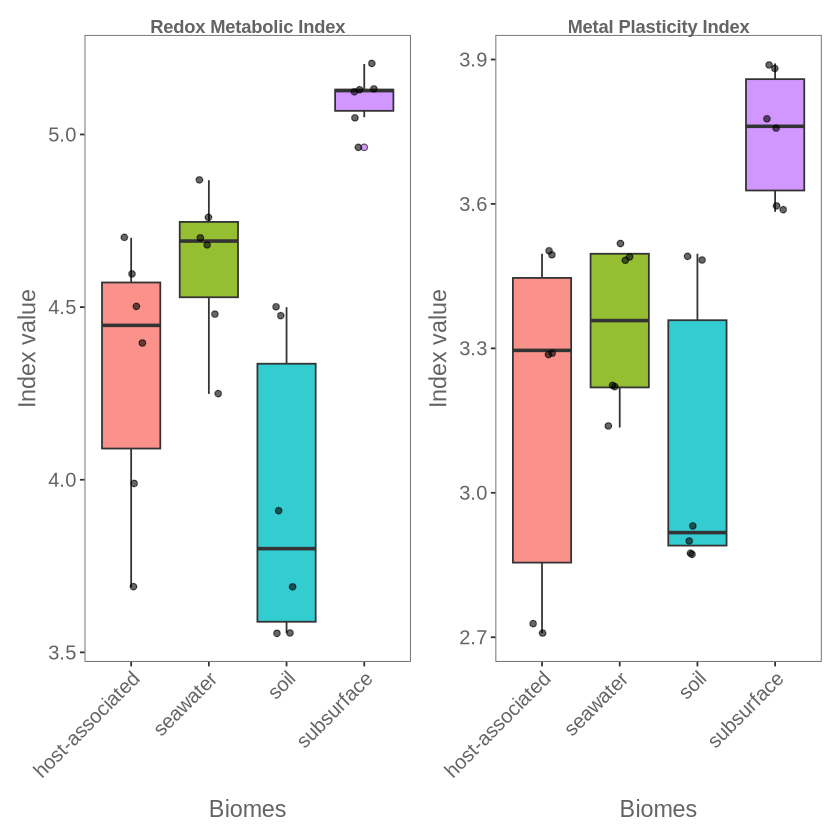

In [50]:
library(ggplot2)
library(patchwork)  # for combining plots side-by-side; install with install.packages("patchwork") if needed



# --- 2. Your data table with the two indexes ---
# Replace this with read.delim("your_file.tsv") or however you're loading it.
# It must contain a "samples" column to merge with dt.
index_data <- read.delim("../tables/gm_gathering/redox_metal_plasticity_index_5/redox_metal_indexes.tsv", header = TRUE, sep = "\t")
# index_data should have columns: samples, redox_metabolic_index, metal_plasticty_index

# --- 3. Merge category info with index data ---
merged <- merge(dt, index_data, by = "sample")

# --- 4. Boxplot for redox_metabolic_index ---
p1 <- ggplot(merged, aes(x = biome, y = redox_metabolic_index, fill = biome)) +
  geom_boxplot(outlier.shape = 21, alpha = 0.8) +
  geom_jitter(width = 0.15, size = 1.5, alpha = 0.6) +
  theme_glab() +
  labs(title = "Redox Metabolic Index", x = "Biomes", y = "Index value") +
  theme(
    axis.text.x       = element_text(angle = 45, vjust = 1, hjust = 1, size = 12),
    axis.text.y       = element_text(size = 12),
    axis.title        = element_text(size = 14),
    strip.text.x      = element_text(size = 12),
    strip.text.y      = element_blank(),
    strip.background  = element_blank(),
    legend.title      = element_text(size = 11),
    legend.text       = element_text(size = 10),
    legend.position   = "none"
  )
# --- 5. Boxplot for metal_plasticty_index ---
p2 <- ggplot(merged, aes(x = biome, y = metal_plasticity_index, fill = biome)) +
  geom_boxplot(outlier.shape = 21, alpha = 0.8) +
  geom_jitter(width = 0.15, size = 1.5, alpha = 0.6) +
  theme_glab() +
  labs(title = "Metal Plasticity Index", x = "Biomes", y = "Index value") +  
  theme(
    axis.text.x       = element_text(angle = 45, vjust = 1, hjust = 1, size = 12),
    axis.text.y       = element_text(size = 12),
    axis.title        = element_text(size = 14),
    strip.text.x      = element_text(size = 12),
    strip.text.y      = element_blank(),
    strip.background  = element_blank(),
    legend.title      = element_text(size = 11),
    legend.text       = element_text(size = 10),
    legend.position   = "none"
  )
# --- 6. Combine side-by-side ---
combined_plot <- p1 + p2
combined_plot

# Optionally save
ggsave("boxplots_redox_metal.svg", combined_plot, width = 12, height = 8, dpi = 300)

In [49]:
plot_scatter(combined_df_2, "redox_metabolic_index", "metal_plasticty_index","biome","samples")

ERROR: Error in geom_text_repel(size = 3, show.legend = FALSE): could not find function "geom_text_repel"


In [ ]:
# taxa <- as.data.frame(read_delim("../tables/ko_carbon_metab.csv",
#                     delim = ',',  # Note: read.delim uses 'sep', read_delim uses 'delim'
#                     locale = locale(decimal_mark = ",")
#                     ))

# rownames(taxa) <- taxa$ko

In [ ]:
# Generating Phyloseq Object
# phy <- phyloseq(
#   otu_table(as.matrix(otu), taxa_are_rows = T),
#   tax_table(as.matrix(taxa_df)),
#   sample_data(env)
# )

In [ ]:
df <- read.delim("/home/edotacca/working_dir/geomosaic_cookbook/tables/metal_indexes_rb/metal_indexes-fixed.tsv", row.names = 1)
colnames(df)[c(1,2)] <- c("rmi","rpi")


In [ ]:

plot_scatter <- function(df) {
  x_var <- df$rmi
  y_var <- df$rpi
  
  ggplot(df, aes(x = .data[[x_var]], y = .data[[y_var]], label = rownames(df))) +
    geom_point(size = 3, color = "steelblue") +
    geom_text_repel(size = 3) +
    labs(
      x = x_var,
      y = y_var,
      title = paste("Scatterplot:", x_var, "vs", y_var),
    ) +
    theme_glab()
}

In [ ]:
# combined dataframe
#write_tsv(combined_df, "../tables/metal_indexes_rb/object_concat.tsv")



In [ ]:
combined_df <- merge(df_concat, env_12,
                   by.x = "row.names",      # Look at row names for the first df
                   by.y = "Geomosaic_sample")   # Look at the column for the second df

In [ ]:
#View(combined_df)

In [ ]:
plot_scatter <- function(df, x_col, y_col, color_col) {
  # We use x_col and y_col as strings (e.g., "rmi")
  ggplot(df, aes(x = .data[[x_col]], 
                 y = .data[[y_col]],
                 color = .data[[color_col]], # This adds the F/S coloring
                 label = .data[["CollectionID"]])) +
    geom_point(size = 3) +
    geom_text_repel(size = 3, show.legend = FALSE) + # hide 'a' from legend
    labs(
      x = x_col,
      y = y_col,
      color = color_col,
      title = paste("Scatterplot:", x_col, "vs", y_col)
    ) +
    theme_glab() +
    # Optional: ensure F and S have distinct, clean colors
    scale_color_brewer(palette = "Set1") 
}


In [ ]:
plot_scatter(combined_df, "rmi", "rpi", "Geomosaic_sample_type")

In [ ]:
plot_boxplot <- function(df, x_col, y_col, fill_col) {
  ggplot(df, aes(x = .data[[x_col]], 
                 y = .data[[y_col]], 
                 fill = .data[[fill_col]])) +
    # The boxplot shows the median and quartiles
    geom_boxplot(outlier.shape = NA, alpha = 0.7) + 
    # Adding jittered points helps see the 12 samples individually
    geom_jitter(width = 0.2, size = 2, alpha = 0.8) +
    labs(
      x = x_col,
      y = y_col,
      fill = fill_col,
      title = paste("Boxplot of", y_col, "by", x_col)
    ) +
    theme_glab() + 
    scale_fill_brewer(palette = "Set1")
}


In [ ]:
plot_boxplot(combined_df, "Geomosaic_sample_type", "rmi", "Geomosaic_sample_type")

In [ ]:
plot_boxplot(combined_df, "Geomosaic_sample_type", "rpi", "Geomosaic_sample_type")

Extended number of samples CR18

In [ ]:
env_34 <- read_delim("../cr18_r_env_34.csv",
                     delim = ",",
                     locale = locale(decimal_mark = ","))

df_extended <- read.delim("../cr18_rmi_rpi.tsv", header = TRUE, row.names = 1)

colnames(df_extended)[c(1, 2)] <- c("rmi", "rpi")


In [ ]:
env_24 <- read_delim("../tables/cr18_env_geomosaic_24_samples.csv",
                     delim = ",",
                     locale = locale(decimal_mark = ","))

df_36 <- read.delim("../tables/gm_gathering/redox_metal_plasticity_index/redox_metal_indexes.tsv", header = TRUE)


In [ ]:
# Move row names of df_extended to a real column first
#df_extended$sample <- rownames(df_extended)
#df_36$sample <- rownames(df_36)
env_24 <- env_24[-1, ]  # remove row 1 (which is the annotation line)

head(df_36, 3)
head(env_24, 3)

#combined_df <- merge(df_extended, env_34, by = "row.names")
#combined_df <- merge(df_extended, env_34, by.x = "sample", by.y = "Geomosaic_sample")
combined_df <- merge(env_24,df_36, by.x = "Geomosaic_samples", by.y = "sample")

rownames(combined_df) <- combined_df$Geomosaic_samples

In [ ]:
colnames(combined_df)
head(combined_df, 5)


In [ ]:
plot_scatter(combined_df, "redox_metabolic_index", "metal_plasticty_index", "sample_type")

In [ ]:
plot_scatter(combined_df, "redox_metabolic_index", "ph", "sample_type")

In [ ]:
plot_scatter(combined_df, "metal_plasticty_index", "ph", "sample_type")

In [ ]:
plot_scatter(combined_df, "metal_plasticty_index", "spc", "sample_type")

In [ ]:
plot_scatter(combined_df, "redox_metabolic_index", "temp", "sample_type")

In [ ]:
plot_scatter(combined_df, "metal_plasticty_index", "do", "sample_type")

In [ ]:
plot_scatter_metal <- function(df, x_col, y_col, color_col) {
  # We use x_col and y_col as strings (e.g., "rmi")
  ggplot(df, aes(x = .data[[x_col]], 
                 y = log10(.data[[y_col]]),

                 color = .data[[color_col]], # This adds the F/S coloring
                 label = .data[["CollectionID"]])) +
    geom_point(size = 3, na.rm = TRUE) +
    geom_text_repel(size = 3, show.legend = FALSE, na.rm = TRUE) + # hide 'a' from legend
    labs(
      x = x_col,
      y = y_col,
      color = color_col,
      title = paste("Scatterplot:", x_col, "vs", y_col)
    ) +
    theme_glab() +
    # Optional: ensure F and S have distinct, clean colors
    scale_color_brewer(palette = "Set1") 
}

In [ ]:
combined_df$mg <- as.numeric(combined_df$mg)

In [ ]:
plot_scatter_metal(combined_df, "redox_metabolic_index", "mg", "sample_type")

In [ ]:
plot_scatter_metal(combined_df, "metal_plasticty_index", "mg", "sample_type")

In [ ]:
plot_scatter(combined_df, "redox_metabolic_index", "spc", "sample_type")

In [ ]:
plot_boxplot(combined_df, "sample_type", "redox_metabolic_index", "sample_type")

In [ ]:
plot_boxplot(combined_df, "sample_type", "metal_plasticty_index", "sample_type")

### 36 Sample plots


In [ ]:
plot_boxplot(combined_df, "Geomosaic_sample_type", "rmi", "Geomosaic_sample_type")

In [ ]:
plot_boxplot(combined_df, "Geomosaic_sample_type", "rpi", "Geomosaic_sample_type")

In [ ]:

plot_boxplot(combined_df, "tectonicType4", "rpi", "tectonicType4")


In [ ]:
plot_boxplot(combined_df, "tectonicType4", "rmi", "tectonicType4")